In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pymc as pm

from pymc_marketing.clv import GammaGammaModel, ParetoNBDModel
from pymc_marketing.clv.utils import rfm_summary
from pymc_marketing.clv import ParetoNBDModel  # or your exact transaction model class

from scipy.stats import spearmanr

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report
)

In [2]:
df_calibration = pd.read_csv('calibration.csv')
df_holdout = pd.read_csv('holdout.csv')
df_lifetimes = pd.read_csv('lifetimes.csv')

df_calibration["order_date"] = pd.to_datetime(df_calibration["order_date"])
df_holdout["order_date"] = pd.to_datetime(df_holdout["order_date"])

print('df_calibration')
df_calibration.info()

print('df_holdout')
df_holdout.info()

df_calibration
<class 'pandas.DataFrame'>
RangeIndex: 16478 entries, 0 to 16477
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16478 non-null  int64         
 1   Customer ID      16478 non-null  int64         
 2   order_date       16478 non-null  datetime64[us]
 3   total_amount     16478 non-null  float64       
 4   number_of_items  16478 non-null  int64         
 5   Country          16478 non-null  str           
 6   order_id         16478 non-null  str           
 7   scaled_time      16478 non-null  str           
 8   scaled_time2     16478 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 1.1 MB
df_holdout
<class 'pandas.DataFrame'>
RangeIndex: 12565 entries, 0 to 12564
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 

In [3]:
# Create customer-level RFM summary
summary = rfm_summary(
    transactions=df_calibration,
    customer_id_col="Customer ID",
    datetime_col="order_date",
    monetary_value_col="total_amount",
    time_unit="D",
    include_first_transaction=True,
    sort_transactions=True,
).reset_index()

# Fit Gamma-Gamma on repeat customers only
gg_data = summary[summary["frequency"] > 0].copy()

gg_model = GammaGammaModel(data=gg_data)
gg_model.fit(method="map")

# Predict aov / expected spend for each customer
pred_aov = gg_model.expected_customer_spend(data=summary)

summary["predicted_aov"] = pred_aov.mean(("chain", "draw")).values

Output()

## Evaluation of Gamma-Gamma

In [4]:
# Collaplsing 
cal_cust = df_calibration.groupby("Customer ID", as_index=False).agg(order_count=("order_id", "nunique"), 
                            calibration_aov=("total_amount", "mean"), calibration_spend=("total_amount", "sum"))

hold_cust = df_holdout.groupby("Customer ID", as_index=False).agg(order_count=("order_id", "nunique"), 
                            actual_aov=("total_amount", "mean"), actual_clv=("total_amount", "sum"))

df_clv = cal_cust.merge(hold_cust, on="Customer ID", how="left", suffixes=("_calibration", "_holdout")).fillna(0)

df_clv = df_clv.merge(
    summary[["customer_id", "frequency", "monetary_value", "predicted_aov"]],
    left_on="Customer ID",
    right_on="customer_id",
    how="left"
)

df_clv = df_clv.drop(
    columns=["customer_id", "frequency", "monetary_value"]
)

print('df_clv')

df_clv.info()

df_clv
<class 'pandas.DataFrame'>
RangeIndex: 4261 entries, 0 to 4260
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              4261 non-null   int64  
 1   order_count_calibration  4261 non-null   int64  
 2   calibration_aov          4261 non-null   float64
 3   calibration_spend        4261 non-null   float64
 4   order_count_holdout      4261 non-null   float64
 5   actual_aov               4261 non-null   float64
 6   actual_clv               4261 non-null   float64
 7   predicted_aov            4261 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 266.4 KB


In [6]:
mask = df_clv["order_count_holdout"] > 0

y_true = df_clv.loc[mask, "actual_aov"]
y_pred = df_clv.loc[mask, "predicted_aov"]
y_calib = df_clv.loc[mask, "calibration_aov"]

print("Gamma-Gamma Prediction Performance")
print("=" * 40)
print(f"Customers evaluated    : {len(df_clv)}")
print(f"Mean actual AOV        : {y_true.mean():.2f}")

print("Comparing Gamma-Gamma versus Holdout")
print("-" * 40)
print(f"Mean predicted AOV     : {y_pred.mean():.2f}")
print(f"MAE                    : {mean_absolute_error(y_true, y_pred):.2f}")
print(f"RMSE                   : {root_mean_squared_error(y_true, y_pred):.2f}")
print(f"R²                     : {r2_score(y_true, y_pred):.4f}")
print(f"Spearman               : {spearmanr(y_true, y_pred).correlation:.4f}")
print(f"WAPE                   : {np.abs(y_true - y_pred).sum() / y_true.sum():.4f}")

# Calibration vs Holdout
print("Comparing Calibration versus Holdout")
print("-" * 40)
print(f"Mean calibration AOV   : {y_calib.mean():.2f}")
print(f"MAE                    : {mean_absolute_error(y_true, y_calib):.2f}")
print(f"RMSE                   : {root_mean_squared_error(y_true, y_calib):.2f}")
print(f"R²                     : {r2_score(y_true, y_calib):.4f}")
print(f"Spearman               : {spearmanr(y_true, y_calib).correlation:.4f}")
print(f"WAPE                   : {np.abs(y_true - y_calib).sum() / y_true.sum():.4f}")

Gamma-Gamma Prediction Performance
Customers evaluated    : 4261
Mean actual AOV        : 434.41
Comparing Gamma-Gamma versus Holdout
----------------------------------------
Mean predicted AOV     : 441.41
MAE                    : 165.22
RMSE                   : 324.69
R²                     : 0.6091
Spearman               : 0.6940
WAPE                   : 0.3803
Comparing Calibration versus Holdout
----------------------------------------
Mean calibration AOV   : 446.17
MAE                    : 175.64
RMSE                   : 389.13
R²                     : 0.4385
Spearman               : 0.7021
WAPE                   : 0.4043


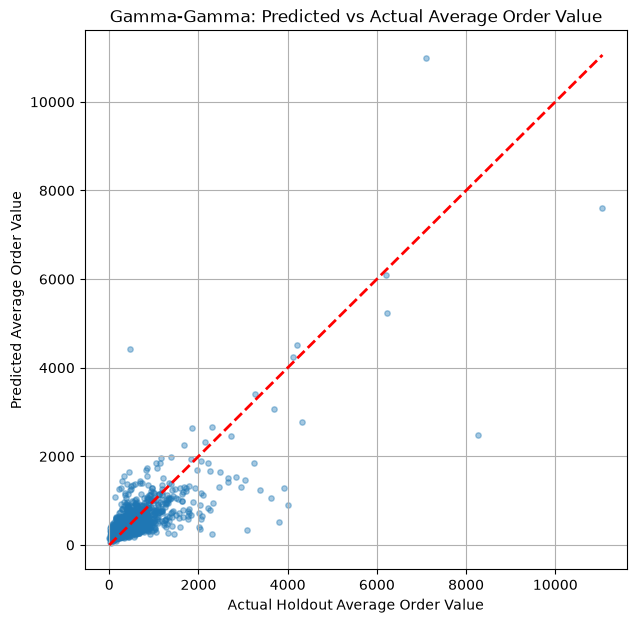

In [7]:
eval_nonzero = df_clv[df_clv["order_count_holdout"] > 0]

plt.figure(figsize=(7,7))

plt.scatter(
    eval_nonzero["actual_aov"],
    eval_nonzero["predicted_aov"],
    alpha=0.4,
    s=15
)

mx = max(
    eval_nonzero["actual_aov"].max(),
    eval_nonzero["predicted_aov"].max()
)

plt.plot([0, mx], [0, mx], "r--", linewidth=2)

plt.xlabel("Actual Holdout Average Order Value")
plt.ylabel("Predicted Average Order Value")
plt.title("Gamma-Gamma: Predicted vs Actual Average Order Value")
plt.grid(True)

plt.show()

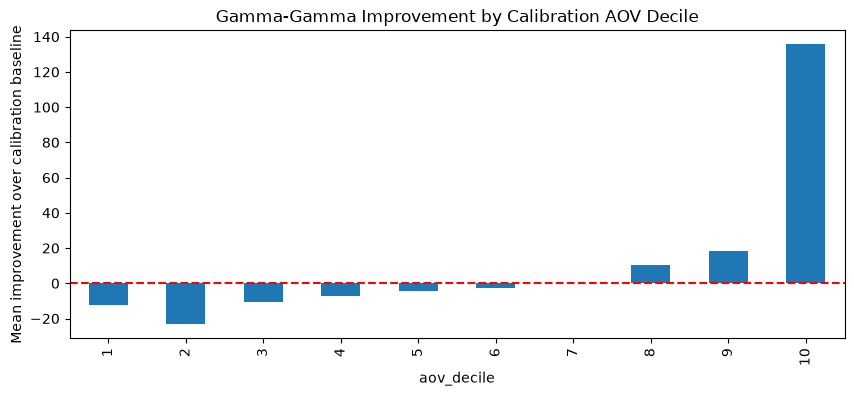

In [7]:
# Create calibration AOV deciles
eval_nonzero["aov_decile"] = pd.qcut(
    eval_nonzero["calibration_aov"],
    10,
    labels=False,
    duplicates="drop"
) + 1

eval_nonzero["gg_error"] = (
    eval_nonzero["predicted_aov"]
    - eval_nonzero["actual_aov"]
).abs()

eval_nonzero["baseline_error"] = (
    eval_nonzero["calibration_aov"]
    - eval_nonzero["actual_aov"]
).abs()

eval_nonzero["improvement"] = (
    eval_nonzero["baseline_error"]
    - eval_nonzero["gg_error"]
)

improvement_by_decile = (
    eval_nonzero
    .groupby("aov_decile")["improvement"]
    .mean()
)

improvement_by_decile.plot(kind="bar", figsize=(10,4))
plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Mean improvement over calibration baseline")
plt.title("Gamma-Gamma Improvement by Calibration AOV Decile")
plt.show()

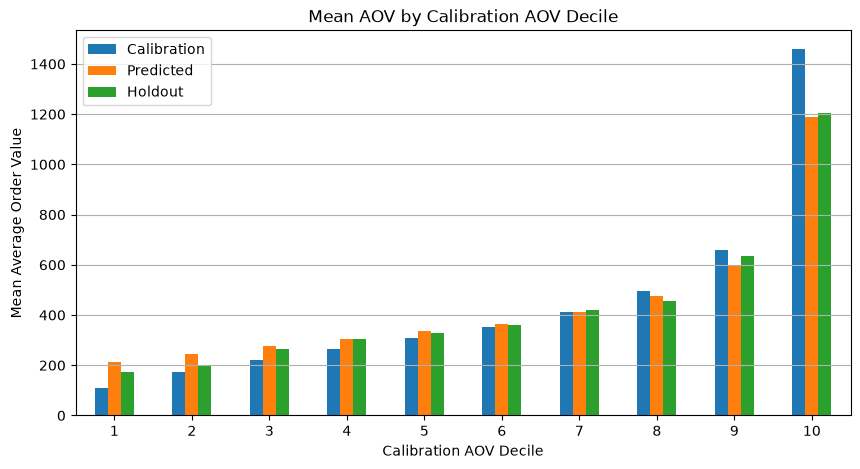

In [8]:

# Mean values by decile
decile_plot = (
    eval_nonzero
    .groupby("aov_decile", as_index=False)
    .agg(
        Holdout=("actual_aov", "mean"),
        Calibration=("calibration_aov", "mean"),
        Predicted=("predicted_aov", "mean")
    )
)

# Plot
ax = decile_plot.plot(
    x="aov_decile",
    y=[ "Calibration", "Predicted", "Holdout"],
    kind="bar",
    figsize=(10,5)
)

ax.set_xlabel("Calibration AOV Decile")
ax.set_ylabel("Mean Average Order Value")
ax.set_title("Mean AOV by Calibration AOV Decile")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.show()

## CLV

In [10]:
df_clv = df_clv.merge(
    df_lifetimes[
        ["customer_id", "predicted_order_count"]
    ],
    left_on="Customer ID",
    right_on="customer_id",
    how="left"
).drop(columns="customer_id")

<class 'pandas.DataFrame'>
RangeIndex: 4261 entries, 0 to 4260
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  4261 non-null   int64  
 1   order_count_calibration      4261 non-null   int64  
 2   avg_order_value_calibration  4261 non-null   float64
 3   total_value_calibration      4261 non-null   float64
 4   order_count_holdout          4261 non-null   float64
 5   avg_order_value_holdout      4261 non-null   float64
 6   total_value_holdout          4261 non-null   float64
 7   predicted_zeta               4261 non-null   float64
 8   predicted_transactions       4261 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 299.7 KB


In [12]:
df_clv["predicted_clv"] = (
    df_clv["predicted_order_count"]
    * df_clv["predicted_aov"]
)

In [13]:
df_clv["actual_clv"] = (
    df_clv["actual_clv"]
)

In [18]:
y_true = df_clv["actual_clv"]
y_pred = df_clv["predicted_clv"]

rmse = root_mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

actual_total_clv = df_clv["actual_clv"].sum()
predicted_total_clv = df_clv["predicted_clv"].sum()

print(f"Actual total CLV    : {actual_total_clv:,.2f}")
print(f"Predicted total CLV : {predicted_total_clv:,.2f}")

error = predicted_total_clv - actual_total_clv
pct_error = error / actual_total_clv * 100

print(f"Absolute error      : {error:,.2f}")
print(f"Percentage error    : {pct_error:.2f}%")

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.4f}")

from scipy.stats import pearsonr

corr, p_value = pearsonr(y_true, y_pred)

print(f"Pearson correlation : {corr:.4f}")
print(f"P-value             : {p_value:.3e}")

from scipy.stats import spearmanr

rho, p_value = spearmanr(y_true, y_pred)

print(f"Spearman correlation : {rho:.4f}")
print(f"P-value              : {p_value:.3e}")

results = {
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "Pearson": corr,
    "Spearman": rho,
}

for metric, value in results.items():
    print(f"{metric:<10}: {value:.4f}")


    

Actual total CLV    : 7,026,132.87
Predicted total CLV : 8,419,594.50
Absolute error      : 1,393,461.63
Percentage error    : 19.83%
RMSE : 3853.684
MAE  : 1172.769
R²   : 0.7991
Pearson correlation : 0.9003
P-value             : 0.000e+00
Spearman correlation : 0.6213
P-value              : 0.000e+00
RMSE      : 3853.6836
MAE       : 1172.7688
R2        : 0.7991
Pearson   : 0.9003
Spearman  : 0.6213


In [19]:
summary = pd.DataFrame({
    "Metric": [
        "Actual Total CLV",
        "Predicted Total CLV",
        "Difference",
        "Percentage Error (%)"
    ],
    "Value": [
        actual_total_clv,
        predicted_total_clv,
        error,
        pct_error
    ]
})

print(summary)

                 Metric         Value
0      Actual Total CLV  7.026133e+06
1   Predicted Total CLV  8.419595e+06
2            Difference  1.393462e+06
3  Percentage Error (%)  1.983255e+01


In [20]:
actual_total_clv = df_clv["actual_clv"].sum()
predicted_total_clv = df_clv["predicted_clv"].sum()

actual_mean_clv = df_clv["actual_clv"].mean()
predicted_mean_clv = df_clv["predicted_clv"].mean()

actual_median_clv = df_clv["actual_clv"].median()
predicted_median_clv = df_clv["predicted_clv"].median()

print(f"Actual total CLV      : {actual_total_clv:,.2f}")
print(f"Predicted total CLV   : {predicted_total_clv:,.2f}")
print()

print(f"Actual mean CLV       : {actual_mean_clv:,.2f}")
print(f"Predicted mean CLV    : {predicted_mean_clv:,.2f}")
print()

print(f"Actual median CLV     : {actual_median_clv:,.2f}")
print(f"Predicted median CLV  : {predicted_median_clv:,.2f}")

Actual total CLV      : 7,026,132.87
Predicted total CLV   : 8,419,594.50

Actual mean CLV       : 1,648.94
Predicted mean CLV    : 1,975.97

Actual median CLV     : 316.68
Predicted median CLV  : 965.00


In [24]:
df_clv["clv_error"] = (
    df_clv["predicted_clv"]
    - df_clv["actual_clv"]
)

print(f"Mean Error (Bias): {df_clv['clv_error'].mean():.2f}")


from sklearn.metrics import mean_absolute_percentage_error

mask = df_clv["actual_clv"] > 0

mape = mean_absolute_percentage_error(
    df_clv.loc[mask, "actual_clv"],
    df_clv.loc[mask, "predicted_clv"]
)

print(f"MAPE (actual CLV > 0): {mape:.2%}")

wape = (
    df_clv["clv_error"].abs().sum()
    / df_clv["actual_clv"].sum()
)

print(f"WAPE: {wape:.2%}")


summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R²",
        "Pearson",
        "Spearman",
        "Actual Total CLV",
        "Predicted Total CLV",
        "Actual Mean CLV",
        "Predicted Mean CLV",
        "Actual Median CLV",
        "Predicted Median CLV",
        "Bias",
        "WAPE"
    ],
    "Value": [
        rmse,
        mae,
        r2,
        corr,
        rho,
        actual_total_clv,
        predicted_total_clv,
        actual_mean_clv,
        predicted_mean_clv,
        actual_median_clv,
        predicted_median_clv,
        df_clv["clv_error"].mean(),
        wape
    ]
})

print(summary)

Mean Error (Bias): 327.03
MAPE (actual CLV > 0): 153.81%
WAPE: 71.12%
                  Metric         Value
0                   RMSE  3.853684e+03
1                    MAE  1.172769e+03
2                     R²  7.990992e-01
3                Pearson  9.003038e-01
4               Spearman  6.213204e-01
5       Actual Total CLV  7.026133e+06
6    Predicted Total CLV  8.419595e+06
7        Actual Mean CLV  1.648940e+03
8     Predicted Mean CLV  1.975967e+03
9      Actual Median CLV  3.166800e+02
10  Predicted Median CLV  9.650021e+02
11                  Bias  3.270269e+02
12                  WAPE  7.112259e-01


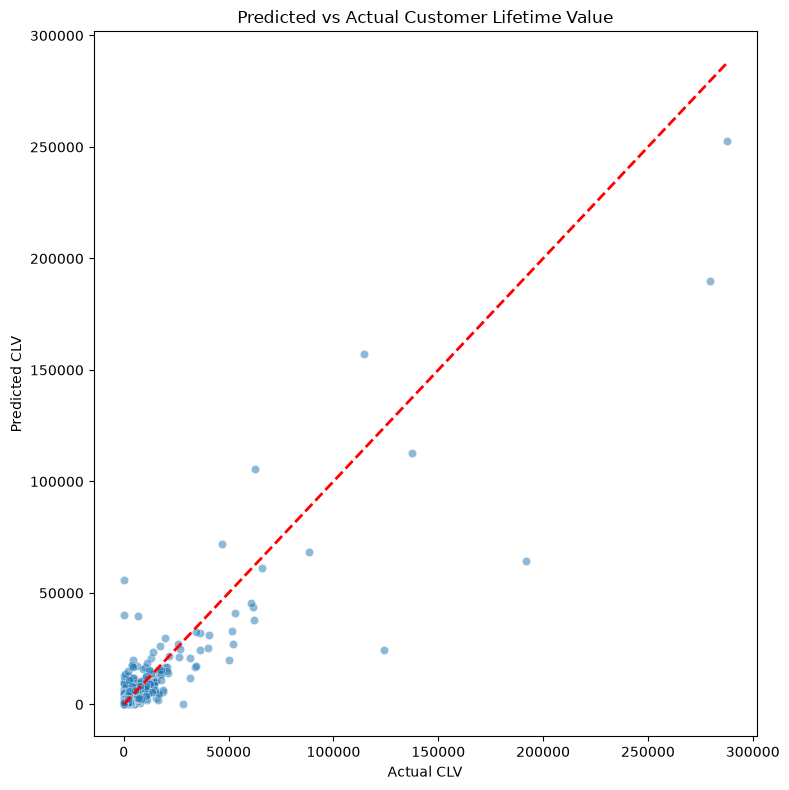

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df_clv,
    x="actual_clv",
    y="predicted_clv",
    alpha=0.5
)

# 45-degree reference line
max_val = max(
    df_clv["actual_clv"].max(),
    df_clv["predicted_clv"].max()
)

plt.plot([0, max_val], [0, max_val], "r--", linewidth=2)

plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Predicted vs Actual Customer Lifetime Value")

plt.tight_layout()
plt.show()

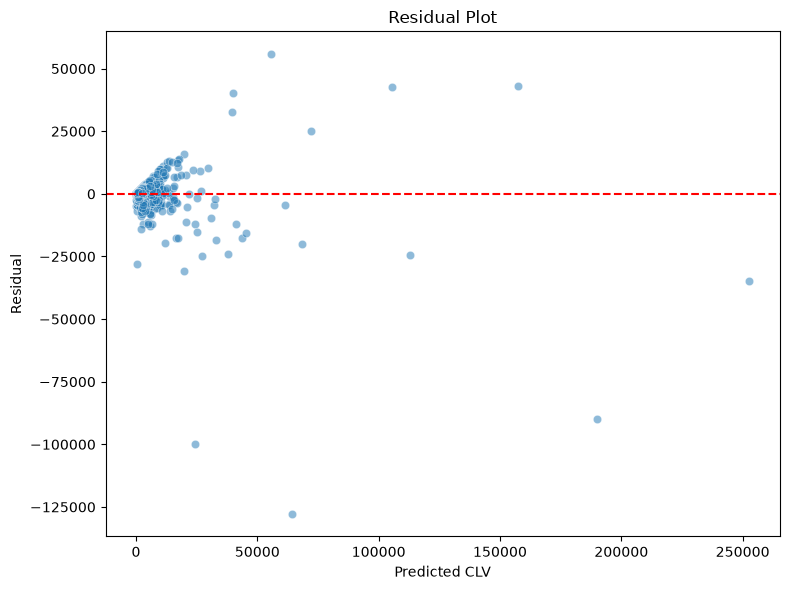

In [26]:
df_clv["residual"] = (
    df_clv["predicted_clv"]
    - df_clv["actual_clv"]
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clv,
    x="predicted_clv",
    y="residual",
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted CLV")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

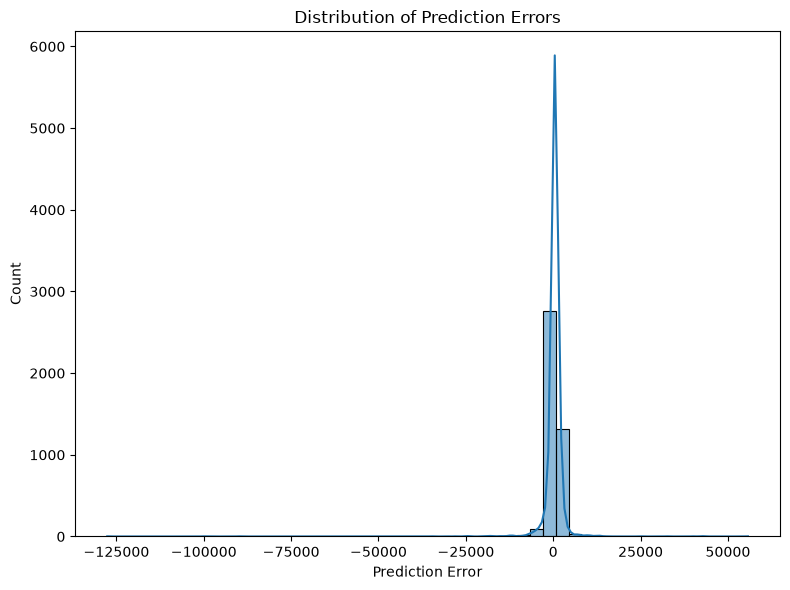

In [27]:
plt.figure(figsize=(8,6))

sns.histplot(
    df_clv["residual"],
    bins=50,
    kde=True
)

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [28]:
df_clv["pred_decile"] = pd.qcut(
    df_clv["predicted_clv"],
    10,
    labels=False,
    duplicates="drop"
) + 1

decile_summary = (
    df_clv
    .groupby("pred_decile", observed=False)
    .agg(
        actual_mean=("actual_clv","mean"),
        predicted_mean=("predicted_clv","mean"),
        customers=("Customer ID","count")
    )
    .reset_index()
)

display(decile_summary)

,pred_decile,actual_mean,predicted_mean,customers
0,1,110.411499,225.788239,427
1,2,255.276502,355.439338,426
2,3,289.144343,517.051394,426
3,4,383.382796,680.828107,426
4,5,436.173430,866.237012,426
5,6,566.795047,1081.538600,426
6,7,830.648310,1366.464570,426
7,8,1362.801784,1857.495800,426
8,9,2094.645117,2697.872107,426
9,10,10163.731646,10115.061162,426


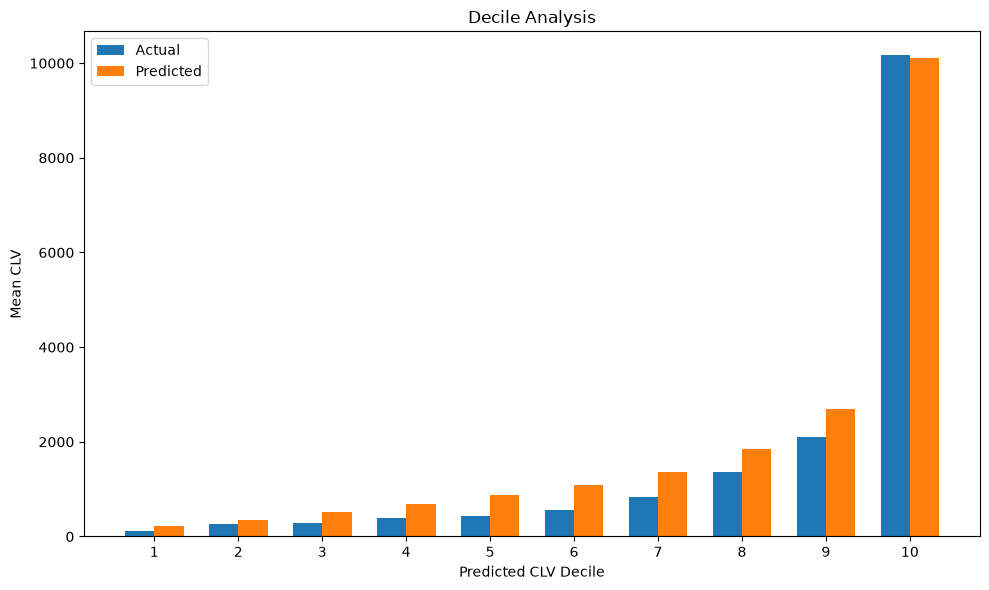

In [29]:
x = np.arange(len(decile_summary))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x-width/2,
    decile_summary["actual_mean"],
    width,
    label="Actual"
)

plt.bar(
    x+width/2,
    decile_summary["predicted_mean"],
    width,
    label="Predicted"
)

plt.xticks(x, decile_summary["pred_decile"])

plt.xlabel("Predicted CLV Decile")
plt.ylabel("Mean CLV")
plt.title("Decile Analysis")

plt.legend()

plt.tight_layout()
plt.show()

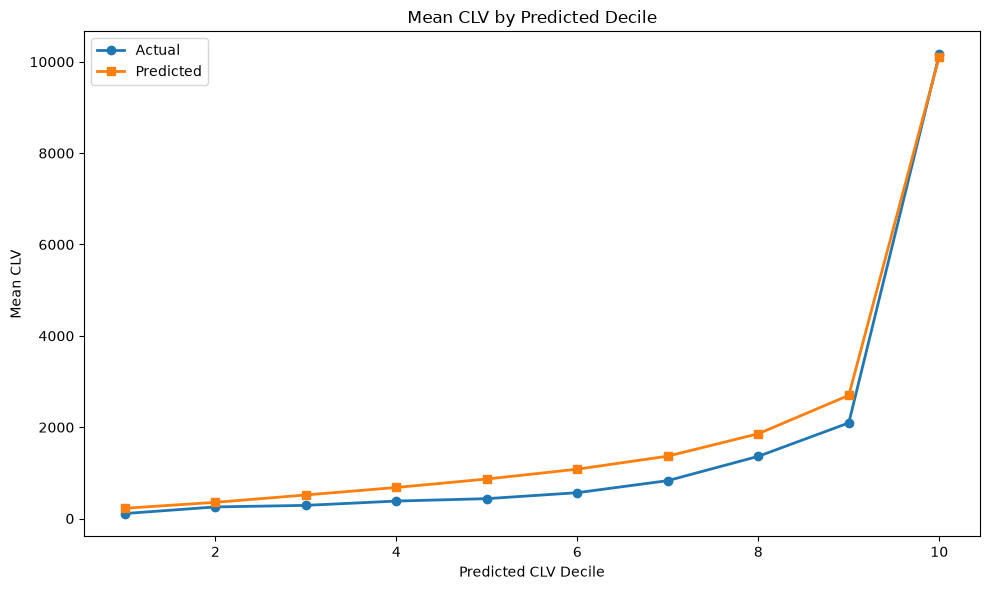

In [30]:
plt.figure(figsize=(10,6))

plt.plot(
    decile_summary["pred_decile"],
    decile_summary["actual_mean"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    decile_summary["pred_decile"],
    decile_summary["predicted_mean"],
    marker="s",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Predicted CLV Decile")
plt.ylabel("Mean CLV")
plt.title("Mean CLV by Predicted Decile")

plt.legend()

plt.tight_layout()
plt.show()

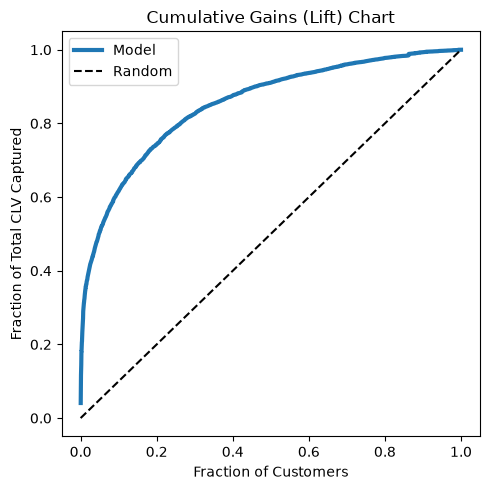

In [33]:
lift = (
    df_clv
    .sort_values("predicted_clv", ascending=False)
    .reset_index(drop=True)
)

lift["cum_actual"] = lift["actual_clv"].cumsum()
lift["cum_actual_pct"] = (
    lift["cum_actual"]
    / lift["actual_clv"].sum()
)

lift["cum_customer_pct"] = (
    np.arange(1, len(lift)+1)
    / len(lift)
)

plt.figure(figsize=(5,5))

plt.plot(
    lift["cum_customer_pct"],
    lift["cum_actual_pct"],
    linewidth=3,
    label="Model"
)

plt.plot(
    [0,1],
    [0,1],
    "k--",
    label="Random"
)

plt.xlabel("Fraction of Customers")
plt.ylabel("Fraction of Total CLV Captured")
plt.title("Cumulative Gains (Lift) Chart")

plt.legend()

plt.tight_layout()
plt.show()

In [34]:
lift = (
    df_clv
    .sort_values("predicted_clv", ascending=False)
    .reset_index(drop=True)
)

total_actual = lift["actual_clv"].sum()

for pct in [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]:
    n = int(np.ceil(len(lift) * pct))

    captured = (
        lift.iloc[:n]["actual_clv"].sum()
        / total_actual
    )

    print(f"Top {pct:>5.0%} customers capture {captured:6.2%} of actual CLV")

Top    1% customers capture 32.47% of actual CLV
Top    5% customers capture 50.60% of actual CLV
Top   10% customers capture 61.65% of actual CLV
Top   20% customers capture 74.36% of actual CLV
Top   30% customers capture 82.62% of actual CLV
Top   50% customers capture 91.07% of actual CLV
